In [1]:
import mne
from mne.preprocessing import ICA
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn.functional as F
from tqdm import tqdm
import torch.nn as nn

from vae_model import NoiseVAE
from resunet import DeepDSP_UNetRes
from datasets_inf import EEGDenoiseDatasetInf
from datasets import EEGDenoiseDataset

In [2]:
ecg_raw = mne.io.read_raw_brainvision('H095/H095_scan.vhdr', preload=True)

Extracting parameters from H095/H095_scan.vhdr...
Setting channel info structure...


C:\Users\npras\AppData\Local\Temp\ipykernel_58964\3475735705.py:1: RuntimeWarning: No coordinate information found for channels ['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  ecg_raw = mne.io.read_raw_brainvision('H095/H095_scan.vhdr', preload=True)


Reading 0 ... 24974399  =      0.000 ...  4994.880 secs...


C:\Users\npras\AppData\Local\Temp\ipykernel_58964\3475735705.py:1: RuntimeWarning: Not setting positions of 6 misc channels found in montage:
['M1', 'M2', 'EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  ecg_raw = mne.io.read_raw_brainvision('H095/H095_scan.vhdr', preload=True)


In [10]:
ecg_raw.plot()

Channels marked as bad:
none


In [3]:
ecg_ch = ecg_raw.info["ch_names"][-1]
ecg_raw.pick([ecg_ch])
ecg_raw.set_annotations(None)
ecg_raw.resample(512.)
clean_ecg = ecg_raw.copy().crop(tmin=343.008, tmax=475.898)

sfreq = ecg_raw.info["sfreq"]

clean_ecg_data = clean_ecg.get_data()

# Create minimal info for this signal
info = mne.create_info(ch_names=['ECG'], sfreq=sfreq, ch_types='eeg')

# Rebuild as a new RawArray
clean_ecg = mne.io.RawArray(clean_ecg_data, info)

Creating RawArray with float64 data, n_channels=1, n_times=68041
    Range : 0 ... 68040 =      0.000 ...   132.891 secs
Ready.


In [8]:
clean_ecg.plot()

Channels marked as bad:
none


Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\npras\miniconda3\envs\eeg_denoising_venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


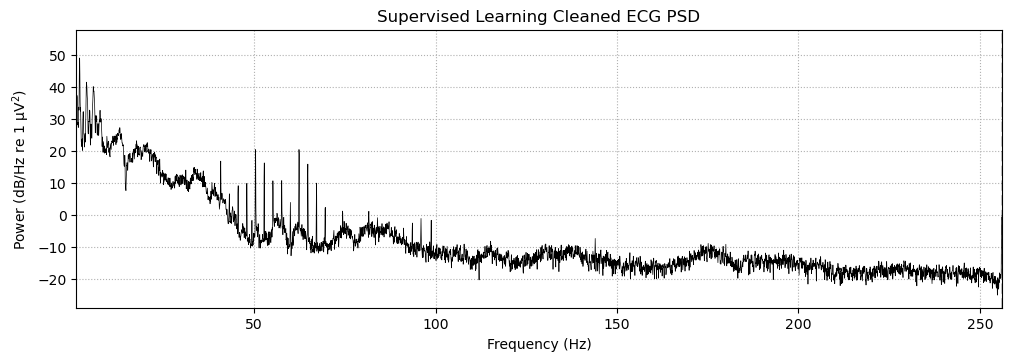

In [29]:
psd_supervised_cleaned = clean_ecg.compute_psd(method='welch', fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_supervised_cleaned.plot(average=True, dB=True)
fig.axes[0].set_title("Supervised Learning Cleaned ECG PSD")
plt.show()

In [65]:
contaminated_ecg = ecg_raw.copy().crop(tmin=563.39, tmax=1520.998)
contaminated_ecg.plot()

Channels marked as bad:
none


In [4]:
sfreq = 512.0  # Hz
channel_name = 'Fp1'

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def load_model(weight_path: str, in_channels: int) -> torch.nn.Module:
    model = DeepDSP_UNetRes(in_channels=in_channels, out_channels=1, nb=6).to(DEVICE)
    state = torch.load(weight_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model

def denorm(x, m, sd):
    # x: [1, 1, T] or [1, C, T]; m, sd: scalars as tensors
    return x * sd.view(1,1,1) + m.view(1,1,1)

def run_one(model, x, y, m, sd):
    """Run model, subtract predicted noise on main channel, denorm all."""
    with torch.no_grad():
        pred_noise = model(x)                 # [1, 1, T]
        cleaned    = x[:, 0:1, :] - pred_noise
    # denormalize
    cleaned_raw = denorm(cleaned, m, sd)      # [1, 1, T]
    input_raw   = denorm(x, m, sd)            # [1, C, T]
    y_raw       = denorm(y, m, sd)            # [1, 1, T]
    return cleaned_raw.squeeze().cpu().numpy(), input_raw.squeeze().cpu().numpy(), y_raw.squeeze().cpu().numpy()


def reconstruct_raw(ds, model, device, label):
    """Run inference for a given dataset+model and return MNE Raw objects."""
    cleaned_windows = []
    contaminated_windows = []

    for i in tqdm(range(len(ds)), desc=f"Running inference ({label})"):
        # Fetch window
        x, y, _, _, m, sd, _, _ = ds[i]
        x = x.unsqueeze(0).to(device)
        y = y.unsqueeze(0).to(device)
        m, sd = m.to(device), sd.to(device)

        # Run model
        cleaned, input_raw, _ = run_one(model, x, y, m, sd)

        # Handle possible shape differences
        if input_raw.ndim == 1:
            main_channel = input_raw
        else:
            main_channel = input_raw[0]

        cleaned_windows.append(np.ravel(cleaned))        # always [T]
        contaminated_windows.append(np.ravel(main_channel))

    # --- Reconstruct continuous signals ---
    cleaned_concat = np.concatenate(cleaned_windows, axis=-1)
    contaminated_concat = np.concatenate(contaminated_windows, axis=-1)

    # --- Wrap into MNE Raw objects ---
    info = mne.create_info(ch_names=[channel_name], sfreq=sfreq, ch_types='eeg')
    raw_clean = mne.io.RawArray(cleaned_concat[np.newaxis, :], info)
    raw_noisy = mne.io.RawArray(contaminated_concat[np.newaxis, :], info)

    return raw_clean, raw_noisy

subj_dir = Path("data_segmented_95_10_TR_all_channels_with_ecg_interference/95")
w_adj0   = "models/10_TR_unet_0_sensors.pt"  # your model weights (adjacent sensors OFF)

ds_adj0 = EEGDenoiseDatasetInf(
subj_dir,
use_adjacent=False,
seed=0,
channels="single",
main_channel=24,
)

model_adj0 = load_model(w_adj0, in_channels=1)

# --- Run for both models ---
raw_clean_0, raw_noisy_0 = reconstruct_raw(ds_adj0, model_adj0, DEVICE, label="model0 (no adjacents)")

# --- Visualize ---
print("\nDisplaying contaminated vs cleaned EEG for model0:")
raw_noisy_0.plot(title='Model 0 — Contaminated EEG', scalings='auto')
raw_clean_0.plot(title='Model 0 — Cleaned EEG', scalings='auto')

Loaded 25 channels from dataset.
ECG Channel Detected


Running inference (model0 (no adjacents)): 100%|██████████| 766/766 [00:13<00:00, 57.66it/s]

Creating RawArray with float64 data, n_channels=1, n_times=490240
    Range : 0 ... 490239 =      0.000 ...   957.498 secs
Ready.
Creating RawArray with float64 data, n_channels=1, n_times=490240
    Range : 0 ... 490239 =      0.000 ...   957.498 secs
Ready.



Displaying contaminated vs cleaned EEG for model0:
Using qt as 2D backend.


Channels marked as bad:
none
Channels marked as bad:
none


Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


c:\Users\npras\miniconda3\envs\eeg_denoising_venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


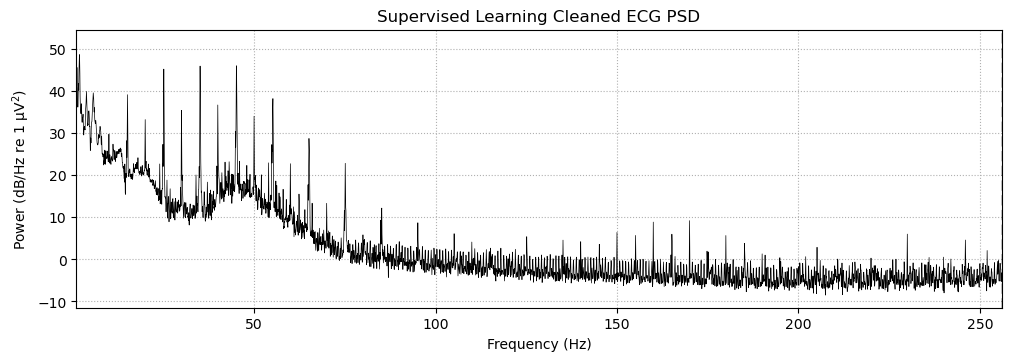

Channels marked as bad:
none
Channels marked as bad:
none


In [ ]:
psd_supervised_cleaned = raw_clean_0.compute_psd(method='welch', fmin=1, fmax=256, n_fft=4096*2, n_overlap=2048)
fig = psd_supervised_cleaned.plot(average=True, dB=True)
fig.axes[0].set_title("Supervised Learning Cleaned ECG PSD")
plt.show()

In [5]:
clean_ecg.plot(title='clean_ecg', scalings='auto');
raw_clean_0.plot(title='raw_clean', scalings='auto');
raw_noisy_0.plot(title='raw_noisy', scalings='auto');

Channels marked as bad:
none
Channels marked as bad:
none
Channels marked as bad:
none


In [ ]:
#For subject 95: clean:{0.545,1.580}, denoised:{0.432,1.375}
clean_qrs = clean_ecg.copy().crop(tmin=2.625, tmax=3.511)
denoised_qrs = raw_clean_0.copy().crop(tmin=83.034, tmax=83.977)
noisy_qrs = raw_noisy_0.copy().crop(tmin=83.034, tmax=83.977)
clean_qrs.plot()
denoised_qrs.plot()

Channels marked as bad:
none
Channels marked as bad:
none


## Clean vs Denoised

In [75]:
import numpy as np
import mne

def align_and_extract(raw_a: mne.io.BaseRaw, raw_b: mne.io.BaseRaw):
    """Resample B to A's sfreq if needed, then return 1D numpy arrays of equal length."""
    ra = raw_a.copy()
    rb = raw_b.copy()
    if ra.info['sfreq'] != rb.info['sfreq']:
        rb.resample(ra.info['sfreq'], npad='auto')

    xa = ra.get_data()[0]  # assume single-channel after your .pick()
    xb = rb.get_data()[0]

    # equalize length (defensive)
    n = min(xa.shape[-1], xb.shape[-1])
    xa = xa[:n]
    xb = xb[:n]
    return xa, xb

def rmse(x, y):
    return float(np.sqrt(np.mean((x - y) ** 2)))

def pearson_r(x, y):
    return float(np.corrcoef(x, y)[0, 1])

# --- use your segments ---
xa, xb = align_and_extract(clean_qrs, denoised_qrs)

# 1) Amplitude-space metrics (units of your signal, e.g., µV)
rmse_amp = rmse(xa, xb)
r_amp    = pearson_r(xa, xb)

# 2) Shape-only metrics (z-score each to remove baseline/scale)
xa_z = (xa - xa.mean()) / (xa.std() + 1e-12)
xb_z = (xb - xb.mean()) / (xb.std() + 1e-12)
rmse_z = rmse(xa_z, xb_z)
r_z    = pearson_r(xa_z, xb_z)

print(f"RMSE (amplitude): {rmse_amp:.6f} | Pearson r (amplitude): {r_amp:.6f} | RMSE (z-scored): {rmse_z:.6f} | Pearson r (z-scored): {r_z:.6f}")


RMSE (amplitude): 0.000382 | Pearson r (amplitude): 0.645703 | RMSE (z-scored): 0.841780 | Pearson r (z-scored): 0.645703


## Clean vs Noisy

In [76]:
# --- use your segments ---
xa, xb = align_and_extract(clean_qrs, noisy_qrs)

# 1) Amplitude-space metrics (units of your signal, e.g., µV)
rmse_amp = rmse(xa, xb)
r_amp    = pearson_r(xa, xb)

# 2) Shape-only metrics (z-score each to remove baseline/scale)
xa_z = (xa - xa.mean()) / (xa.std() + 1e-12)
xb_z = (xb - xb.mean()) / (xb.std() + 1e-12)
rmse_z = rmse(xa_z, xb_z)
r_z    = pearson_r(xa_z, xb_z)

print(f"RMSE (amplitude): {rmse_amp:.6f} | Pearson r (amplitude): {r_amp:.6f} | RMSE (z-scored): {rmse_z:.6f} | Pearson r (z-scored): {r_z:.6f}")

RMSE (amplitude): 0.000561 | Pearson r (amplitude): 0.267916 | RMSE (z-scored): 1.210028 | Pearson r (z-scored): 0.267916


### VAE attempt

In [ ]:
# ---------- device ----------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------- helpers ----------
def load_noise_vae(ckpt_path: str) -> NoiseVAE:
    ckpt = torch.load(ckpt_path, map_location="cpu")
    vae = NoiseVAE(T=ckpt["T"], z_dim=ckpt["z_dim"]).to(DEVICE)
    vae.load_state_dict(ckpt["state_dict"])
    vae.eval()
    for p in vae.parameters():
        p.requires_grad_(False)
    return vae

def per_window_norm_match_dataset(x: torch.Tensor, eps: float = 1e-8):
    """
    EXACT match to dataset normalization:
    m = mean(x), sd = std(x) + 1e-8  (NO CLAMP)
    x: 1D tensor [T]
    """
    m = x.mean()
    sd = x.std() + eps
    return (x - m) / sd, m, sd

def stitch_windows(windows: torch.Tensor, hop: int, crossfade: int = 0) -> torch.Tensor:
    """
    windows: [N, T]  (DENORMALIZED per window already)
    hop: hop size; for seg_overlap=0.0, hop == T
    crossfade: if non-overlap, small boundary smoothing (e.g., 32-128)
    """
    N, T = windows.shape
    if hop == T:
        if crossfade <= 0:
            return windows.reshape(-1)
        fade = min(crossfade, T // 4)
        ramp = torch.linspace(0, 1, steps=fade, device=windows.device, dtype=windows.dtype)
        out = windows[0].clone()
        for i in range(1, N):
            a = out[-fade:].clone()
            b = windows[i, :fade].clone()
            blend = a * (1 - ramp) + b * ramp
            out = torch.cat([out[:-fade], blend, windows[i, fade:]], dim=0)
        return out
    else:
        # Hann WOLA for overlap
        out_len = hop * (N - 1) + T
        acc = torch.zeros(out_len, dtype=windows.dtype, device=windows.device)
        wsum = torch.zeros_like(acc)
        win = torch.hann_window(T, periodic=False, dtype=windows.dtype, device=windows.device)
        for i in range(N):
            s = i * hop
            acc[s:s + T] += windows[i] * win
            wsum[s:s + T] += win
        wsum = torch.clamp(wsum, min=1e-8)
        return acc / wsum

def build_feature_extractor(vae: NoiseVAE, upto: int = 2) -> nn.Module:
    # Early encoder blocks only (texture/noise). Frozen.
    enc_children = list(vae.enc.children())
    upto = max(0, min(upto, len(enc_children) - 1))
    feat = nn.Sequential(*enc_children[:upto + 1]).eval().to(DEVICE)
    for p in feat.parameters():
        p.requires_grad_(False)
    return feat

def feature_loss(feature_extractor: nn.Module, x1: torch.Tensor, x2: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(feature_extractor(x1), feature_extractor(x2))

def band_keep_fft_ortho(x_1d: torch.Tensor, sfreq: float, f_low: float, f_high: float) -> torch.Tensor:
    """
    Keep only [f_low, f_high] Hz using unitary FFTs (no energy scaling).
    x_1d: [T]
    """
    T = x_1d.shape[-1]
    X = torch.fft.rfft(x_1d, dim=-1, norm="ortho")
    freqs = torch.fft.rfftfreq(T, d=1.0 / sfreq).to(x_1d.device)
    mask = ((freqs >= f_low) & (freqs <= f_high)).to(X.dtype)
    X = X * mask
    return torch.fft.irfft(X, n=T, dim=-1, norm="ortho")


# ---------- MAP variants ----------
def map_estimate_noise(
    vae: NoiseVAE,
    feature_extractor: nn.Module,
    x_contam_norm: torch.Tensor,   # [1,1,T_model]
    steps: int = 300,
    lr: float = 3e-2,
    lam_z: float = 1e-2,
    lam_dc: float = 1e-4,
    lam_feat: float = 2e-3,
    alpha_recon: float = 0.5,
    init: str = "enc",
):
    with torch.no_grad():
        mu, _ = vae.encode(x_contam_norm)
    z = (mu.detach().clone() if init == "enc" else torch.zeros_like(mu))
    z.requires_grad_(True)
    opt = torch.optim.Adam([z], lr=lr)

    T_use = x_contam_norm.shape[-1]
    for _ in range(steps):
        xhat = vae.decode(z)  # [1,1,T_model]
        xhat_crop = xhat[..., :T_use]

        l1 = F.l1_loss(xhat_crop, x_contam_norm[..., :T_use])
        l2 = F.mse_loss(xhat_crop, x_contam_norm[..., :T_use])
        recon = alpha_recon * l1 + (1 - alpha_recon) * l2

        reg_z = lam_z * (z ** 2).mean()
        feat = lam_feat * feature_loss(feature_extractor, x_contam_norm[..., :T_use], xhat_crop)
        dc = lam_dc * xhat.mean(dim=[1, 2]).pow(2).mean()

        loss = recon + reg_z + feat + dc
        opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        xhat = vae.decode(z)
    return xhat, z


def map_estimate_noise_bandmatch(
    vae: NoiseVAE,
    x_contam_norm: torch.Tensor,   # [1,1,T_model]
    sfreq: float = 512.0,
    band=(20.0, 200.0),
    steps: int = 200,
    lr: float = 2e-3,
    lam_z: float = 5e-3,
    lam_dc: float = 1e-4,
    alpha: float = 0.7,
):
    """
    Optimize z so that band-passed predicted noise matches band-passed input (in normalized space).
    """
    with torch.no_grad():
        mu, _ = vae.encode(x_contam_norm)
    z = mu.detach().clone().requires_grad_(True)
    opt = torch.optim.Adam([z], lr=lr)

    T_use = x_contam_norm.shape[-1]
    x_band = band_keep_fft_ortho(x_contam_norm.squeeze(), sfreq, band[0], band[1]).view(1, 1, -1)

    for _ in range(steps):
        xhat = vae.decode(z)[..., :T_use]
        n_band = band_keep_fft_ortho(xhat.squeeze(), sfreq, band[0], band[1]).view(1, 1, -1)

        l1 = F.l1_loss(n_band, x_band)
        l2 = F.mse_loss(n_band, x_band)
        recon = alpha * l1 + (1 - alpha) * l2

        reg_z = lam_z * (z ** 2).mean()
        dc = lam_dc * xhat.mean(dim=[1, 2]).pow(2).mean()

        loss = recon + reg_z + dc
        opt.zero_grad(); loss.backward(); opt.step()

    with torch.no_grad():
        xhat = vae.decode(z)
    return xhat, z


# ---------- main sequencer ----------
def run_sequence_vae_ola(
    vae: NoiseVAE,
    T_model: int,
    windows_np: np.ndarray,        # [N, T_orig] contaminated windows (single channel)
    seg_overlap: float = 0.0,      # MUST match your segmentation
    inference_mode: str = "posterior_mean",  # 'posterior_mean' | 'map' | 'map_band'
    # MAP params (if used)
    steps: int = 150,
    lr: float = 2e-3,
    lam_z: float = 1e-2,
    lam_dc: float = 1e-4,
    lam_feat: float = 2e-3,
    alpha_recon: float = 0.5,
    feature_upto: int = 2,
    # Subtraction controls
    sfreq: float = 512.0,
    noise_band=None,               # e.g., (20.0, 200.0) or None
    scale_subtraction: bool = True,
    g_clip=(0.0, 1.25),
    crossfade_nonoverlap: int = 64,
    verbose_every: int | None = 200,
):
    assert 0.0 <= seg_overlap < 1.0
    N, T_orig = windows_np.shape
    assert T_model >= T_orig, f"T_model ({T_model}) must be >= T_orig ({T_orig})."
    hop = max(1, int(round(T_orig * (1.0 - seg_overlap))))

    feat_extractor = build_feature_extractor(vae, upto=feature_upto) if inference_mode == "map" else None

    cleaned_denorm_windows = []
    dbg_pre, dbg_post, dbg_g = [], [], []

    for i in tqdm(range(N), desc="VAE inference"):
        # to torch
        x = torch.from_numpy(windows_np[i].astype(np.float32))  # [T_orig]

        # per-window norm (MATCH dataset: no clamp)
        x_norm, m, sd = per_window_norm_match_dataset(x)
        x_norm = x_norm.to(DEVICE)

        # reflect-pad to T_model
        if T_orig != T_model:
            x_norm_pad = F.pad(x_norm.view(1, 1, -1), (0, T_model - T_orig), mode="reflect")
        else:
            x_norm_pad = x_norm.view(1, 1, -1)

        # predict NOISE in normalized space
        if inference_mode == "posterior_mean":
            with torch.no_grad():
                mu, _ = vae.encode(x_norm_pad)
                xhat_noise_norm = vae.decode(mu)                     # [1,1,T_model]
        elif inference_mode == "map":
            xhat_noise_norm, _ = map_estimate_noise(
                vae, feat_extractor, x_contam_norm=x_norm_pad,
                steps=steps, lr=lr, lam_z=lam_z, lam_dc=lam_dc,
                lam_feat=lam_feat, alpha_recon=alpha_recon, init="enc"
            )
        elif inference_mode == "map_band":
            xhat_noise_norm, _ = map_estimate_noise_bandmatch(
                vae, x_norm_pad, sfreq=sfreq, band=(noise_band or (20.0, 200.0)),
                steps=steps, lr=lr
            )
        else:
            raise ValueError("inference_mode must be 'posterior_mean', 'map', or 'map_band'")

        with torch.no_grad():
            # crop to original
            x_use = x_norm_pad[..., :T_orig].squeeze()
            n_use = xhat_noise_norm[..., :T_orig].squeeze()

            # diagnostics before gating
            pre_ratio = float((n_use.norm() / (x_use.norm() + 1e-8)).item())
            dbg_pre.append(pre_ratio)

            # optional band gate
            if noise_band is not None:
                n_gate = band_keep_fft_ortho(n_use, sfreq=sfreq, f_low=noise_band[0], f_high=noise_band[1])
            else:
                n_gate = n_use

            post_ratio = float((n_gate.norm() / (x_use.norm() + 1e-8)).item())
            dbg_post.append(post_ratio)

            # LS gain (clipped)
            num = torch.dot(n_gate.flatten(), x_use.flatten())
            den = torch.dot(n_gate.flatten(), n_gate.flatten()) + 1e-8
            g = (num / den).item() if scale_subtraction else 1.0
            g = float(np.clip(g, g_clip[0], g_clip[1]))
            dbg_g.append(g)

            if verbose_every and (i % verbose_every == 0):
                print(f"[win {i}] pre ||n||/||x||={pre_ratio:.3f}  post={post_ratio:.3f}  g={g:.3f}")

            # subtract in normalized space
            cleaned_norm = x_use - g * n_gate

            # denormalize per window
            cleaned_denorm = (cleaned_norm * sd.to(DEVICE) + m.to(DEVICE)).cpu()
            cleaned_denorm_windows.append(cleaned_denorm)

    # stack + stitch
    cleaned_denorm_windows = torch.stack(cleaned_denorm_windows, dim=0).to(DEVICE)
    if hop == T_orig:
        cleaned_full_tensor = stitch_windows(cleaned_denorm_windows, hop=hop, crossfade=int(crossfade_nonoverlap))
    else:
        cleaned_full_tensor = stitch_windows(cleaned_denorm_windows, hop=hop, crossfade=0)

    cleaned_full = cleaned_full_tensor.detach().cpu().numpy()
    cleaned_full -= cleaned_full.mean()

    print(f"[summary] mean pre-ratio={np.mean(dbg_pre):.3f}, mean post-ratio={np.mean(dbg_post):.3f}, mean g={np.mean(dbg_g):.3f}")
    return cleaned_full


# Paths (adjust to your setup)
ckpt_path = "models/noise_vae_best.pt"
subj_dir  = Path("data_segmented_91_10_TR_all_channels_with_ecg_interference/91")  # must match your preprocessing
contaminated = np.load(subj_dir / "contaminated.npy", mmap_mode="r")  # [N, C, T]

# Pick channel
ch = 24
windows_np = contaminated[:, ch, :]  # [N, T_orig]

# Load VAE
vae = load_noise_vae(ckpt_path)
T_model = vae.T

# IMPORTANT: seg_overlap must match how you created these windows
cleaned_full = run_sequence_vae_ola(
    vae,
    T_model=T_model,
    windows_np=windows_np,
    seg_overlap=0.0,                    # <-- set correctly for your dataset
    inference_mode="posterior_mean",    # try 'map_band' if you want band alignment
    # For 'map' tuning:
    steps=150, lr=2e-3, lam_z=1e-2, lam_dc=1e-4, lam_feat=2e-3, alpha_recon=0.5,
    feature_upto=2,
    # Subtraction knobs:
    sfreq=512.0,
    noise_band=None,                    # start with None; then try (20.0, 200.0)
    scale_subtraction=True,
    g_clip=(0.0, 1.25),
    crossfade_nonoverlap=64,
    verbose_every=200,
)

# Visualize
sfreq = 512.0
info = mne.create_info(ch_names=['Fp1'], sfreq=sfreq, ch_types='eeg')
raw_clean = mne.io.RawArray(cleaned_full[np.newaxis, :], info)
raw_clean.plot(title="EEG Denoised with VAE (posterior mean, LS-scaled)")


VAE inference:   2%|▏         | 19/766 [00:00<00:08, 89.89it/s]

[win 0] pre ||n||/||x||=0.989  post=0.989  g=0.980


VAE inference:  31%|███       | 237/766 [00:01<00:02, 199.06it/s]

[win 200] pre ||n||/||x||=0.999  post=0.999  g=0.987


VAE inference:  55%|█████▌    | 422/766 [00:02<00:01, 210.23it/s]

...

VAE inference:  83%|████████▎ | 637/766 [00:03<00:00, 235.02it/s]

[win 600] pre ||n||/||x||=0.987  post=0.987  g=0.998


VAE inference: 100%|██████████| 766/766 [00:03<00:00, 196.23it/s]


[summary] mean pre-ratio=0.997, mean post-ratio=0.997, mean g=0.989
Creating RawArray with float64 data, n_channels=1, n_times=441280
    Range : 0 ... 441279 =      0.000 ...   861.873 secs
Ready.


Channels marked as bad:
none


In [ ]:
raw_noisy_0.plot(title='Model 0 — Contaminated EEG', scalings='auto')

Channels marked as bad:
none
Channels marked as bad:
none
